# Reinforcement Learning Q-Maze Pathfinding

This notebook implements a tabular Q-learning Reinforcement Learning (RL) agent that learns to solve a 6x6 gridworld maze with obstacles. We define reward penalties for walls/states, train the agent over 300 episodes, and plot the learned path.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Maze Gridworld Environment
GRID_SIZE = 6
START = (0, 0)
GOAL = (5, 5)

# Obstacle coordinates (walls)
OBSTACLES = {
    (1, 1), (1, 2), (2, 4), (3, 1), (3, 2), (4, 4)
}

# Actions: 0=Up, 1=Right, 2=Down, 3=Left
ACTIONS = [(-1, 0), (0, 1), (1, 0), (0, -1)]

def get_next_state(state, action_idx):
    move = ACTIONS[action_idx]
    next_s = (state[0] + move[0], state[1] + move[1])
    
    # Check boundaries
    if next_s[0] < 0 or next_s[0] >= GRID_SIZE or next_s[1] < 0 or next_s[1] >= GRID_SIZE:
        return state # hit border, stay in place
    # Check obstacles
    if next_s in OBSTACLES:
        return state # hit wall, stay in place
    return next_s

def get_reward(state):
    if state == GOAL:
        return 10.0
    return -0.1 # tiny penalty per step to encourage shortest path



## Tabular Q-Learning Agent Training

We initialize the Q-Table of shape `(GRID_SIZE, GRID_SIZE, 4)` to zeros. The agent explores the maze using an epsilon-greedy policy, updating the values using Bellman's equation:

$$Q(s, a) \leftarrow Q(s, a) + \alpha [R + \gamma \max_{a'} Q(s', a') - Q(s, a)]$$



In [2]:
# Hyperparameters
alpha = 0.1
gamma = 0.95
epsilon = 0.2
episodes = 300

Q = np.zeros((GRID_SIZE, GRID_SIZE, 4))
episode_rewards = []

for ep in range(episodes):
    state = START
    total_reward = 0
    steps = 0
    
    # Decay epsilon
    eps = max(0.01, epsilon * (1 - ep / episodes))
    
    while state != GOAL and steps < 100:
        # Action selection (epsilon-greedy)
        if np.random.rand() < eps:
            action_idx = np.random.choice(4)
        else:
            action_idx = np.argmax(Q[state[0], state[1]])
            
        next_state = get_next_state(state, action_idx)
        reward = get_reward(next_state)
        
        # Bellman update
        best_next_q = np.max(Q[next_state[0], next_state[1]])
        Q[state[0], state[1], action_idx] += alpha * (reward + gamma * best_next_q - Q[state[0], state[1], action_idx])
        
        state = next_state
        total_reward += reward
        steps += 1
        
    episode_rewards.append(total_reward)

print(f"Agent trained for {episodes} episodes.")
print(f"Final Episode Reward: {episode_rewards[-1]:.2f}")



Agent trained for 300 episodes.
Final Episode Reward: 9.10


## Path Extraction & Grid Map Visualization

We trace the optimal path from the learned Q-Table and plot the maze grid. Green represents the start, Red represents the goal, and Blue arrows show the learned optimal navigation path.



In [3]:
# Extract optimal path
state = START
optimal_path = [state]
steps = 0
while state != GOAL and steps < 50:
    action_idx = np.argmax(Q[state[0], state[1]])
    state = get_next_state(state, action_idx)
    optimal_path.append(state)
    steps += 1

print(f"Learned Path Steps: {len(optimal_path)-1}")
print("Path Coordinates:", optimal_path)



Learned Path Steps: 10
Path Coordinates: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (3, 3), (4, 3), (5, 3), (5, 4), (5, 5)]


<cell>:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


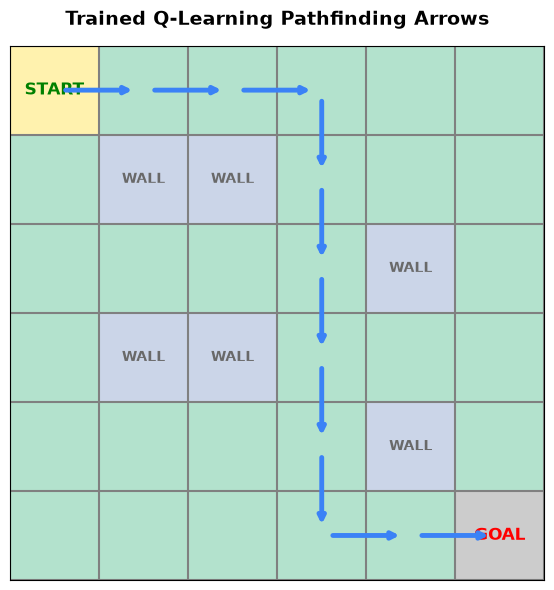

In [4]:
# Plot Maze grid with Matplotlib
grid_map = np.zeros((GRID_SIZE, GRID_SIZE))

# Mark elements
for obs in OBSTACLES:
    grid_map[obs[0], obs[1]] = 1 # Walls
grid_map[START[0], START[1]] = 2 # Start
grid_map[GOAL[0], GOAL[1]] = 3 # Goal

fig, ax = plt.subplots(figsize=(6, 6))
# Show grid
ax.imshow(grid_map, cmap='Pastel2')

# Annotate Start and Goal
ax.text(START[1], START[0], 'START', ha='center', va='center', color='green', fontweight='bold', fontsize=12)
ax.text(GOAL[1], GOAL[0], 'GOAL', ha='center', va='center', color='red', fontweight='bold', fontsize=12)

# Draw Grid lines
ax.set_xticks(np.arange(-.5, GRID_SIZE, 1), minor=True)
ax.set_yticks(np.arange(-.5, GRID_SIZE, 1), minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=1.5)
ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# Overlay learned path arrow indicators
for i in range(len(optimal_path) - 1):
    curr = optimal_path[i]
    nxt = optimal_path[i+1]
    
    # Calculate arrow vector
    dx = nxt[1] - curr[1]
    dy = nxt[0] - curr[0]
    
    # Draw arrow from center of cell to next cell
    ax.annotate(
        "", 
        xy=(nxt[1], nxt[0]), 
        xytext=(curr[1], curr[0]),
        arrowprops=dict(arrowstyle="->", color="#3b82f6", lw=3.5, shrinkA=8, shrinkB=8)
    )

# Mark walls
for obs in OBSTACLES:
    ax.text(obs[1], obs[0], 'WALL', ha='center', va='center', color='dimgray', fontweight='bold', fontsize=10)

plt.title("Trained Q-Learning Pathfinding Arrows", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
